# EDA: prediction performance analysis

This notebook analyzes artifacts produced by `entrypoints/inference.py` under `data/04_predictions`. It focuses on frame-level anomaly detection performance, score distributions, threshold behavior, and per-video timelines.

Set `RUN_ID` below to a specific run, or leave it as `None` to use the latest prediction directory.


In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PRED_ROOT = PROJECT_ROOT / "data" / "04_predictions" / "shanghaitech"
CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoints"
RUN_ID = None  # e.g. "exp001". None uses latest directory under PRED_ROOT.

plt.style.use("default")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)


In [2]:
def read_jsonl(path: Path) -> pd.DataFrame:
    if not path.is_file():
        return pd.DataFrame()
    records = []
    with path.open("r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)


def read_json(path: Path) -> dict:
    if not path.is_file():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))


def latest_run(root: Path) -> Path | None:
    if not root.is_dir():
        return None
    candidates = [path for path in root.iterdir() if path.is_dir()]
    if not candidates:
        return None
    return max(candidates, key=lambda path: path.stat().st_mtime)


def resolve_run_dir(root: Path, run_id: str | None) -> Path:
    if run_id:
        return root / run_id
    selected = latest_run(root)
    if selected is None:
        raise FileNotFoundError(f"No prediction runs found under {root}")
    return selected


def roc_auc_np(labels, scores):
    y = np.asarray(labels).astype(int)
    s = np.asarray(scores).astype(float)
    n_pos = int(y.sum())
    n_neg = int((1 - y).sum())
    if n_pos == 0 or n_neg == 0:
        return None
    ranks = pd.Series(s).rank(method="average").to_numpy()
    auc = (ranks[y == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return float(auc)


def average_precision_np(labels, scores):
    y = np.asarray(labels).astype(int)
    s = np.asarray(scores).astype(float)
    n_pos = int(y.sum())
    if n_pos == 0:
        return None
    order = np.argsort(-s)
    y_sorted = y[order]
    tp = np.cumsum(y_sorted)
    precision = tp / (np.arange(len(y_sorted)) + 1)
    return float((precision * y_sorted).sum() / n_pos)


def roc_curve_np(labels, scores):
    y = np.asarray(labels).astype(int)
    s = np.asarray(scores).astype(float)
    thresholds = np.r_[np.inf, np.unique(s)[::-1], -np.inf]
    rows = []
    p = max(int(y.sum()), 1)
    n = max(int((1 - y).sum()), 1)
    for threshold in thresholds:
        pred = s >= threshold
        tp = int(((pred == 1) & (y == 1)).sum())
        fp = int(((pred == 1) & (y == 0)).sum())
        rows.append({"threshold": threshold, "tpr": tp / p, "fpr": fp / n})
    return pd.DataFrame(rows)


def pr_curve_np(labels, scores):
    y = np.asarray(labels).astype(int)
    s = np.asarray(scores).astype(float)
    thresholds = np.r_[np.inf, np.unique(s)[::-1], -np.inf]
    rows = []
    p = max(int(y.sum()), 1)
    for threshold in thresholds:
        pred = s >= threshold
        tp = int(((pred == 1) & (y == 1)).sum())
        fp = int(((pred == 1) & (y == 0)).sum())
        precision = tp / max(tp + fp, 1)
        recall = tp / p
        rows.append({"threshold": threshold, "precision": precision, "recall": recall})
    return pd.DataFrame(rows)


def threshold_sweep(labels, scores, num_thresholds=200):
    y = np.asarray(labels).astype(int)
    s = np.asarray(scores).astype(float)
    if len(s) == 0:
        return pd.DataFrame()
    if len(np.unique(s)) <= num_thresholds:
        thresholds = np.unique(s)
    else:
        thresholds = np.quantile(s, np.linspace(0, 1, num_thresholds))
    rows = []
    for threshold in thresholds:
        pred = s >= threshold
        tp = int(((pred == 1) & (y == 1)).sum())
        fp = int(((pred == 1) & (y == 0)).sum())
        tn = int(((pred == 0) & (y == 0)).sum())
        fn = int(((pred == 0) & (y == 1)).sum())
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-12)
        rows.append({
            "threshold": float(threshold),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
        })
    return pd.DataFrame(rows).sort_values("f1", ascending=False)


In [3]:
run_dir = resolve_run_dir(PRED_ROOT, RUN_ID)
run_id = run_dir.name

frame_scores = read_jsonl(run_dir / "frame_scores.jsonl")
future_predictions = read_jsonl(run_dir / "future_frame_predictions.jsonl")
metrics = read_json(run_dir / "metrics.json")
checkpoint_ref = (run_dir / "checkpoint_ref.txt").read_text(encoding="utf-8").strip() if (run_dir / "checkpoint_ref.txt").is_file() else None

train_metrics_path = CHECKPOINT_ROOT / run_id / "metrics.jsonl"
train_metrics = read_jsonl(train_metrics_path)

print(f"run_id: {run_id}")
print(f"run_dir: {run_dir}")
print(f"checkpoint: {checkpoint_ref}")
print(f"frame rows: {len(frame_scores):,}")
print(f"prediction rows: {len(future_predictions):,}")
metrics


run_id: exp001
run_dir: /workspace/VAD/data/04_predictions/shanghaitech/exp001
checkpoint: checkpoints/exp001/best.pt
frame rows: 37,260
prediction rows: 9,208


{'average_precision': None,
 'checkpoint_path': 'checkpoints/exp001/best.pt',
 'metrics_error': 'scikit-learn is not installed',
 'num_anomaly_frames': 16972,
 'num_frames': 37260,
 'prediction_records': 9208,
 'roc_auc': None,
 'run_id': 'exp001'}

In [4]:
if frame_scores.empty:
    raise FileNotFoundError(f"No frame_scores.jsonl found in {run_dir}")

summary = {
    "frames": len(frame_scores),
    "videos": frame_scores["video_id"].nunique(),
    "anomaly_frames": int(frame_scores["label"].sum()),
    "normal_frames": int((frame_scores["label"] == 0).sum()),
    "score_mean": frame_scores["score"].mean(),
    "score_std": frame_scores["score"].std(),
    "score_min": frame_scores["score"].min(),
    "score_max": frame_scores["score"].max(),
    "roc_auc": roc_auc_np(frame_scores["label"], frame_scores["score"]),
    "average_precision": average_precision_np(frame_scores["label"], frame_scores["score"]),
}
pd.DataFrame([summary]).T.rename(columns={0: "value"})


,value
frames,3.726000e+04
videos,1.070000e+02
anomaly_frames,1.697200e+04
normal_frames,2.028800e+04
score_mean,1.715003e+06
score_std,1.118146e+05
score_min,1.392447e+06
score_max,2.258384e+06
roc_auc,4.212097e-01
average_precision,3.949985e-01


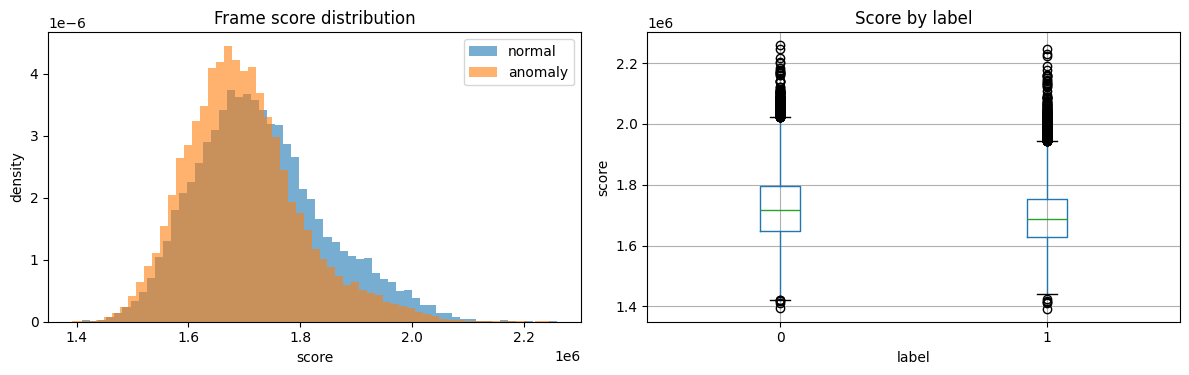

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, group in frame_scores.groupby("label"):
    name = "anomaly" if int(label) == 1 else "normal"
    axes[0].hist(group["score"], bins=60, alpha=0.6, label=name, density=True)
axes[0].set_title("Frame score distribution")
axes[0].set_xlabel("score")
axes[0].set_ylabel("density")
axes[0].legend()

frame_scores.boxplot(column="score", by="label", ax=axes[1])
axes[1].set_title("Score by label")
axes[1].set_xlabel("label")
axes[1].set_ylabel("score")
fig.suptitle("")
plt.tight_layout()


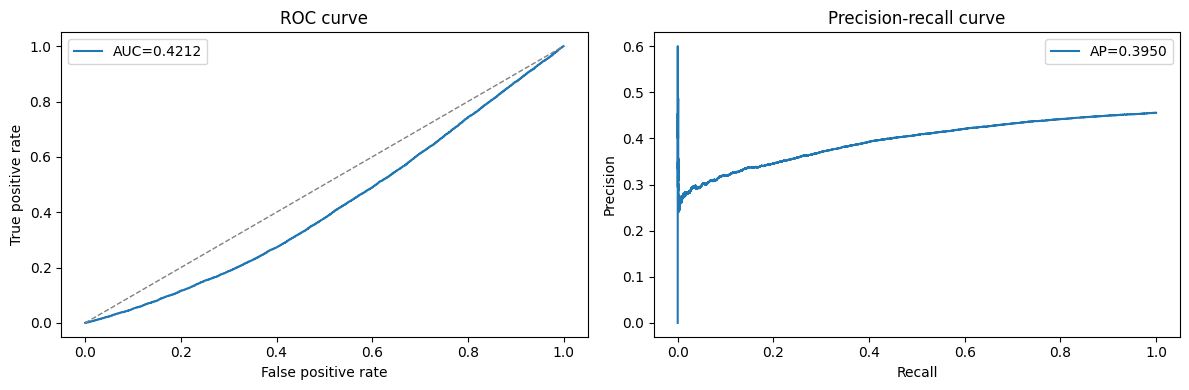

In [6]:
roc = roc_curve_np(frame_scores["label"], frame_scores["score"])
pr = pr_curve_np(frame_scores["label"], frame_scores["score"])
auc = roc_auc_np(frame_scores["label"], frame_scores["score"])
ap = average_precision_np(frame_scores["label"], frame_scores["score"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(roc["fpr"], roc["tpr"], label=f"AUC={auc:.4f}" if auc is not None else "AUC=N/A")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()

axes[1].plot(pr["recall"], pr["precision"], label=f"AP={ap:.4f}" if ap is not None else "AP=N/A")
axes[1].set_title("Precision-recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout()


In [7]:
sweep = threshold_sweep(frame_scores["label"], frame_scores["score"])
cols = ["threshold", "precision", "recall", "f1", "tp", "fp", "tn", "fn"]
sweep[cols].head(10)


,threshold,precision,recall,f1,tp,fp,tn,fn
0,1.392447e+06,0.455502,1.000000,0.625904,16972,20288,0,0
1,1.486383e+06,0.455384,0.994697,0.624750,16882,20190,98,90
2,1.501638e+06,0.455009,0.988864,0.623243,16783,20102,186,189
3,1.513577e+06,0.454439,0.982618,0.621465,16677,20021,267,295
4,1.522571e+06,0.454055,0.976785,0.619935,16578,19933,355,394
5,1.529545e+06,0.453679,0.970952,0.618407,16479,19844,444,493
6,1.535499e+06,0.453122,0.964765,0.616630,16374,19762,526,598
7,1.541004e+06,0.452864,0.959227,0.615257,16280,19669,619,692
8,1.545948e+06,0.452491,0.953453,0.613722,16182,19580,708,790
9,1.550175e+06,0.452381,0.948209,0.612530,16093,19481,807,879


In [8]:
per_video = (
    frame_scores.groupby("video_id")
    .agg(
        frames=("frame_idx", "count"),
        anomaly_frames=("label", "sum"),
        score_mean=("score", "mean"),
        score_max=("score", "max"),
        score_p95=("score", lambda values: values.quantile(0.95)),
        votes_mean=("num_votes", "mean"),
    )
    .reset_index()
)
per_video["anomaly_ratio"] = per_video["anomaly_frames"] / per_video["frames"].clip(lower=1)
per_video.sort_values(["score_p95", "score_max"], ascending=False).head(20)


,video_id,frames,anomaly_frames,score_mean,score_max,score_p95,votes_mean,anomaly_ratio
45,03_0060,352,84,1.915051e+06,2.258384e+06,2.099685e+06,1.977273,0.238636
46,03_0061,208,33,1.934477e+06,2.120380e+06,2.077903e+06,1.961538,0.158654
42,03_0039,448,211,1.913405e+06,2.130024e+06,2.057720e+06,1.982143,0.470982
40,03_0035,352,106,1.938025e+06,2.113373e+06,2.042469e+06,1.977273,0.301136
41,03_0036,424,216,1.910554e+06,2.089628e+06,2.036844e+06,1.981132,0.509434
39,03_0033,280,115,1.898345e+06,2.122767e+06,2.034521e+06,1.971429,0.410714
43,03_0041,424,106,1.889472e+06,2.142785e+06,2.032506e+06,1.981132,0.250000
96,11_0176,304,141,1.871836e+06,2.247773e+06,2.032320e+06,1.973684,0.463816
37,03_0031,496,60,1.916459e+06,2.192141e+06,2.029273e+06,1.983871,0.120968
38,03_0032,376,120,1.918961e+06,2.107965e+06,2.019568e+06,1.978723,0.319149


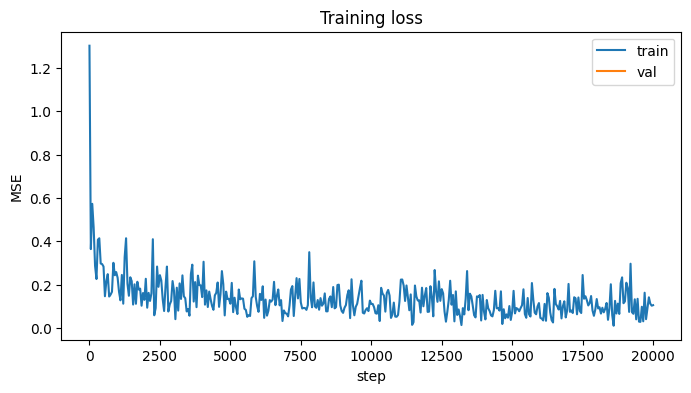

In [9]:
if not train_metrics.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    if "train_loss" in train_metrics:
        ax.plot(train_metrics["step"], train_metrics["train_loss"], label="train")
    if "val_loss" in train_metrics and train_metrics["val_loss"].notna().any():
        ax.plot(train_metrics["step"], train_metrics["val_loss"], label="val")
    ax.set_title("Training loss")
    ax.set_xlabel("step")
    ax.set_ylabel("MSE")
    ax.legend()
else:
    print(f"No training metrics found at {train_metrics_path}")


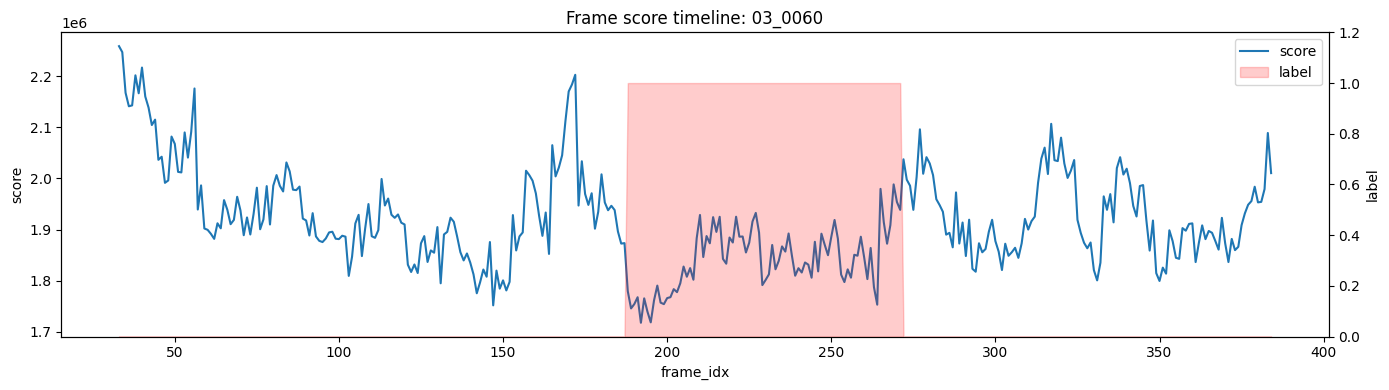

In [10]:
video_id = per_video.sort_values("score_p95", ascending=False).iloc[0]["video_id"]
video = frame_scores[frame_scores["video_id"] == video_id].sort_values("frame_idx")

fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(video["frame_idx"], video["score"], label="score")
ax1.set_title(f"Frame score timeline: {video_id}")
ax1.set_xlabel("frame_idx")
ax1.set_ylabel("score")

ax2 = ax1.twinx()
ax2.fill_between(video["frame_idx"], 0, video["label"], alpha=0.2, color="red", label="label")
ax2.set_ylim(0, 1.2)
ax2.set_ylabel("label")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper right")
plt.tight_layout()


,score_mean,score_std,anomaly_rate,rows
future_offset,,,,
0,1.738654e+06,126717.640570,0.459600,9208
1,1.716822e+06,127558.271997,0.459166,9208
2,1.701669e+06,127390.791980,0.459709,9208
3,1.701176e+06,126636.253379,0.459492,9208
4,1.709632e+06,125940.708474,0.459492,9208
5,1.708123e+06,127197.705169,0.458949,9208
6,1.714984e+06,126947.762978,0.459383,9208
7,1.726901e+06,126367.534862,0.459166,9208


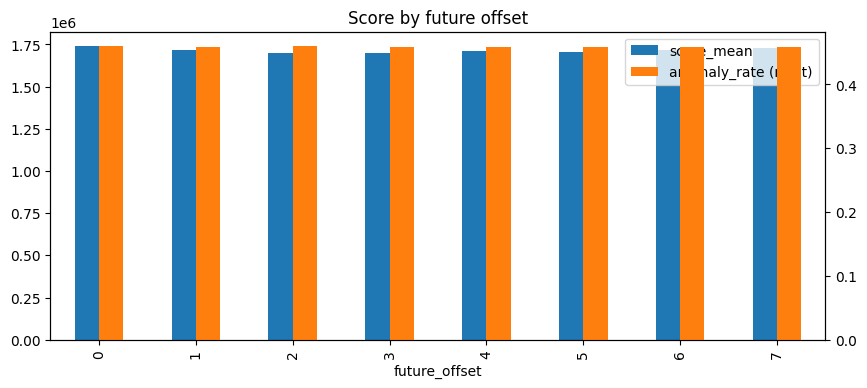

In [11]:
if not future_predictions.empty:
    exploded_rows = []
    for row in future_predictions.itertuples(index=False):
        frames = getattr(row, "future_frames")
        labels = getattr(row, "future_frame_labels")
        scores = getattr(row, "future_frame_scores")
        for offset, (frame_idx, label, score) in enumerate(zip(frames, labels, scores, strict=True)):
            exploded_rows.append({
                "sample_id": row.sample_id,
                "video_id": row.video_id,
                "future_offset": offset,
                "frame_idx": frame_idx,
                "label": label,
                "score": score,
            })
    future_long = pd.DataFrame(exploded_rows)
    offset_summary = future_long.groupby("future_offset").agg(
        score_mean=("score", "mean"),
        score_std=("score", "std"),
        anomaly_rate=("label", "mean"),
        rows=("score", "count"),
    )
    display(offset_summary)
    offset_summary[["score_mean", "anomaly_rate"]].plot(kind="bar", secondary_y="anomaly_rate", figsize=(10, 4), title="Score by future offset")
else:
    print("No future_frame_predictions.jsonl found.")


## Interpretation checklist

- Check whether anomaly scores are separated from normal scores in the distribution plot.
- Prefer frame-level ROC-AUC/AP for ShanghaiTech comparison, because labels are frame-level.
- Use the threshold sweep only after selecting the validation strategy; the top F1 threshold on test is diagnostic, not a deployable threshold.
- Inspect high-score timelines to identify false positives caused by scene changes, camera artifacts, or ambiguous future prediction.
